In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10

# Load the CIFAR-10 dataset
(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
train_images, test_images = train_images / 255.0, test_images / 255.0

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')  # For 10 classes
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.fit(train_images, train_labels, epochs=25)


Epoch 1/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 59s 37ms/step - accuracy: 0.3761 - loss: 1.7216
Epoch 2/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 56s 36ms/step - accuracy: 0.5966 - loss: 1.1516
Epoch 3/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 57s 37ms/step - accuracy: 0.6519 - loss: 0.9986
Epoch 4/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 35ms/step - accuracy: 0.6809 - loss: 0.9136
Epoch 5/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 56s 36ms/step - accuracy: 0.7056 - loss: 0.8503
Epoch 6/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 36ms/step - accuracy: 0.7235 - loss: 0.8018
Epoch 7/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 57s 36ms/step - accuracy: 0.7447 - loss: 0.7402
Epoch 8/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 58s 37ms/step - accuracy: 0.7502 - loss: 0.7155
Epoch 9/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 36ms/step - accuracy: 0.7666 - loss: 0.6741
Epoch 10/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 56s 36ms/step - accuracy: 0.7827 - loss: 0.6292
Epoch 11/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 55s 35ms/step - accuracy: 0.7870 - loss: 0.6068
Epoch 12

In [ ]:
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f'Test accuracy: {test_acc}')

313/313 - 3s - 11ms/step - accuracy: 0.6860 - loss: 1.2769
Test accuracy: 0.6859999895095825


In [ ]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 502,688 (1.92 MB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 335,126 (1.28 MB)

In [ ]:
# Train the model or run it on a sample input
# (use a batch of images from the test set or a single image)
sample_image = test_images[0].reshape(1, 32, 32, 3)  # Reshape for model input if using one image
model.predict(sample_image)  # This will initialize the layers


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


array([[2.3890902e-05, 3.1088472e-08, 2.5798773e-08, 9.9575341e-01,
        1.3346137e-07, 4.1376040e-03, 8.4738735e-05, 3.7756771e-09,
        8.2307658e-08, 1.0767239e-07]], dtype=float32)

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input

# Create a symbolic Input tensor that matches the original model's expected input shape
input_tensor = Input(shape=(32, 32, 3))

# Manually pass the input tensor through the relevant layers of the sequential model
# and collect their outputs as KerasTensors linked to `input_tensor`.
x = input_tensor
collected_outputs = []
for i, layer in enumerate(model.layers):
    x = layer(x) # Apply the layer
    if i < 4: # Collect outputs for the first four layers (Conv2D, MaxPooling2D, Conv2D, MaxPooling2D)
        collected_outputs.append(x)

# Create the activation model using the symbolic input and the collected outputs.
activation_model = Model(inputs=input_tensor, outputs=collected_outputs)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


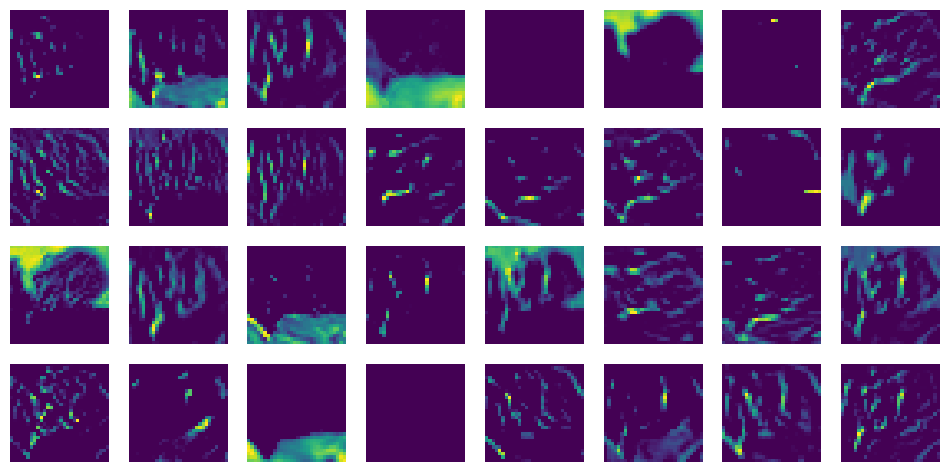

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Select a sample image from your dataset (e.g., the first image in the test set)
sample_image = test_images[0].reshape(1, 32, 32, 3)  # Reshape for model input

# Get activations (output of intermediate layers)
activations = activation_model.predict(sample_image)

# Visualize the output of the first convolutional layer
first_layer_activation = activations[0]
plt.figure(figsize=(12, 12))
for i in range(32):  # 32 filters in the first layer
    plt.subplot(8, 8, i + 1)
    plt.imshow(first_layer_activation[0, :, :, i], cmap='viridis')
    plt.axis('off')
plt.show()

In [ ]:
# Predict on a test image
predictions = model.predict(test_images[:5])  # Predict on the first 5 test images

# Get the predicted class for each image
predicted_classes = np.argmax(predictions, axis=1)

# Get the true labels
true_labels = test_labels[:5]

# Display predictions and true labels
for i in range(5):
    print(f"Image {i+1}:")
    print(f"True Label: {true_labels[i]}")
    print(f"Predicted Class: {predicted_classes[i]}")
    print(f"Predicted Probabilities: {predictions[i]}")
    print("--------")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
Image 1:
True Label: [3]
Predicted Class: 3
Predicted Probabilities: [2.3890971e-05 3.1088650e-08 2.5798872e-08 9.9575341e-01 1.3346201e-07
 4.1376161e-03 8.4738815e-05 3.7756989e-09 8.2307821e-08 1.0767260e-07]
--------
Image 2:
True Label: [8]
Predicted Class: 8
Predicted Probabilities: [2.5190029e-03 6.3500716e-04 1.6046417e-06 3.8142581e-08 9.1152106e-16
 9.6081525e-09 3.6052338e-14 9.9528836e-15 9.9679631e-01 4.8001679e-05]
--------
Image 3:
True Label: [8]
Predicted Class: 1
Predicted Probabilities: [1.6852488e-01 5.1232803e-01 6.3506678e-02 2.6866093e-03 7.9358631e-04
 1.0419980e-03 9.0747108e-06 1.7639591e-01 7.1249031e-02 3.4642299e-03]
--------
Image 4:
True Label: [0]
Predicted Class: 0
Predicted Probabilities: [8.1891096e-01 8.2577219e-07 1.5561451e-01 1.8804458e-03 8.0985938e-06
 8.8651672e-05 1.7320321e-05 1.7144273e-06 2.3476744e-02 6.6137852e-07]
--------
Image 5:
True Label: [6]
Predicted Class: 6
Predicted Probabilities: [2.91719

In [ ]:
history = model.fit(train_images, train_labels, epochs=1, validation_data=(test_images, test_labels))


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 61s 39ms/step - accuracy: 0.8946 - loss: 0.3019 - val_accuracy: 0.6809 - val_loss: 1.3687


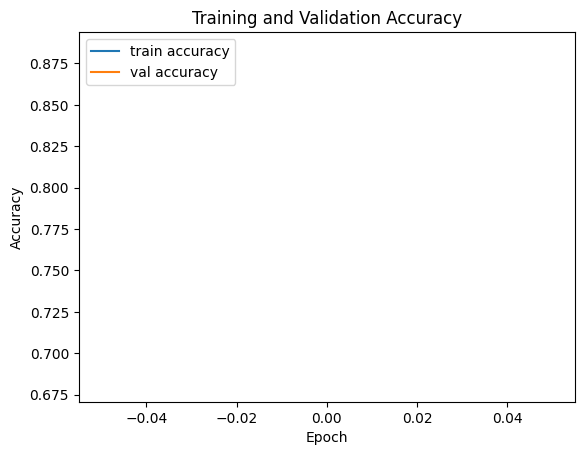

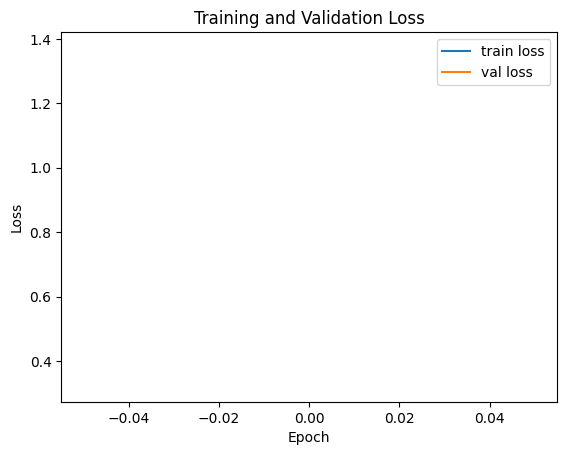

In [12]:
# Plot training & validation accuracy
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='upper left')
plt.show()

# Plot training & validation loss
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()


In [13]:
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f"Test accuracy: {test_acc}")


313/313 - 3s - 10ms/step - accuracy: 0.6809 - loss: 1.3687
Test accuracy: 0.680899977684021
